In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [43]:
# importation du dataset
df = pd.read_csv("/Users/user/Desktop/dataset/bigmart.csv")
df.head(2)

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.300000,Low Fat,0.016047,Dairy,249.809200,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.138000
1,DRC01,5.920000,Regular,0.019278,Soft Drinks,48.269200,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.422800


<div style="background-color:#0b1d51; padding:20px; border-radius:12px;">
    <table style="width:100%; border-collapse:collapse; font-family:Arial, sans-serif;">
        <thead>
            <tr>
                <th style="padding:12px; border-bottom:2px solid #ffffff55; color:#ffeb3b; text-align:left;">Variable</th>
                <th style="padding:12px; border-bottom:2px solid #ffffff55; color:#cddc39; text-align:left;">Description</th>
            </tr>
        </thead>
        <tbody>
            <tr>
                <td style="padding:10px; color:#ffeb3b;">Item_Identifier</td>
                <td style="padding:10px; color:#cddc39;">Identifiant de l'article</td>
            </tr>
            <tr>
                <td style="padding:10px; color:#ffeb3b;">Item_Weight</td>
                <td style="padding:10px; color:#cddc39;">poids de l'article en g</td>
            </tr>
            <tr>
                <td style="padding:10px; color:#ffeb3b;">Item_Fat_Content</td>
                <td style="padding:10px; color:#cddc39;">contenu en matière grasses</td>
            </tr>
            <tr>
                <td style="padding:10px; color:#ffeb3b;">Item_Visibility</td>
                <td style="padding:10px; color:#cddc39;">valeurs de placement de chaque élément : 0 - loin et derrière ; 1 - près et devant</td>
            </tr>
            <tr>
                <td style="padding:10px; color:#ffeb3b;">Item_Type</td>
                <td style="padding:10px; color:#cddc39;">type d'article</td>
            </tr>
            <tr>
                <td style="padding:10px; color:#ffeb3b;">Item_MRP</td>
                <td style="padding:10px; color:#cddc39;">prix de l'article</td>
            </tr>
            <tr>
                <td style="padding:10px; color:#ffeb3b;">Outlet_Identifier</td>
                <td style="padding:10px; color:#cddc39;">identifiant unique de l'enseigne</td>
            </tr>
            <tr>
                <td style="padding:10px; color:#ffeb3b;">Outlet_Establishment_Year</td>
                <td style="padding:10px; color:#cddc39;">Année de création du point de vente</td>
            </tr>
            <tr>
                <td style="padding:10px; color:#ffeb3b;">Outlet_Size</td>
                <td style="padding:10px; color:#cddc39;">taille du magasin (Small, Medium, High)</td>
            </tr>
            <tr>
                <td style="padding:10px; color:#ffeb3b;">Outlet_Location_Type</td>
                <td style="padding:10px; color:#cddc39;">niveau de localisation (Tier1, Tier2, Tier3)</td>
            </tr>
            <tr>
                <td style="padding:10px; color:#ffeb3b;">Outlet_Type</td>
                <td style="padding:10px; color:#cddc39;">type de magasin</td>
            </tr>
            <tr>
                <td style="padding:10px; color:#ffeb3b;">Item_Outlet_Sales</td>
                <td style="padding:10px; color:#cddc39;">montant des ventes du produit dans le magasin</td>
            </tr>
        </tbody>
    </table>
</div>

In [45]:
# Vérification des valeurs manquantes
df.isnull().sum()

Item_Identifier                 0
Item_Weight                  1463
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  2410
Outlet_Location_Type            0
Outlet_Type                     0
Item_Outlet_Sales               0
dtype: int64

In [46]:
# Comptage des valeurs dans la colonne 'Outlet_Size'
df['Outlet_Size'].value_counts()

Outlet_Size
Medium    2793
Small     2388
High       932
Name: count, dtype: int64

In [47]:
# Comptage des valeurs dans la colonne 'Item_Type'
df["Item_Type"].value_counts()

Item_Type
Fruits and Vegetables    1232
Snack Foods              1200
Household                 910
Frozen Foods              856
Dairy                     682
Canned                    649
Baking Goods              648
Health and Hygiene        520
Soft Drinks               445
Meat                      425
Breads                    251
Hard Drinks               214
Others                    169
Starchy Foods             148
Breakfast                 110
Seafood                    64
Name: count, dtype: int64

In [48]:
# Transormation de la colonne Outlet_Establishment_Year de int en type date(année)
# df['Outlet_Establishment_Year'] = pd.to_datetime(df['Outlet_Establishment_Year'],format ='%Y')
df['Outlet_Establishment_Year'] = pd.PeriodIndex(df['Outlet_Establishment_Year'],freq ='Y')

In [49]:
# Affichage des informations de la colonne 'Outlet_Establishment_Year'
df['Outlet_Establishment_Year'].info

<bound method Series.info of 0       1999
1       2009
2       1999
3       1998
4       1987
        ... 
8518    1987
8519    2002
8520    2004
8521    2009
8522    1997
Name: Outlet_Establishment_Year, Length: 8523, dtype: period[Y-DEC]>

In [50]:
# informations sur le dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype        
---  ------                     --------------  -----        
 0   Item_Identifier            8523 non-null   object       
 1   Item_Weight                7060 non-null   float64      
 2   Item_Fat_Content           8523 non-null   object       
 3   Item_Visibility            8523 non-null   float64      
 4   Item_Type                  8523 non-null   object       
 5   Item_MRP                   8523 non-null   float64      
 6   Outlet_Identifier          8523 non-null   object       
 7   Outlet_Establishment_Year  8523 non-null   period[Y-DEC]
 8   Outlet_Size                6113 non-null   object       
 9   Outlet_Location_Type       8523 non-null   object       
 10  Outlet_Type                8523 non-null   object       
 11  Item_Outlet_Sales          8523 non-null   float64      
dtypes: float64(4), objec

In [51]:
# statistiques descriptives du dataset
df.describe()

,Item_Weight,Item_Visibility,Item_MRP,Item_Outlet_Sales
count,7060.000000,8523.000000,8523.000000,8523.000000
mean,12.857645,0.066132,140.992782,2181.288914
std,4.643456,0.051598,62.275067,1706.499616
min,4.555000,0.000000,31.290000,33.290000
25%,8.773750,0.026989,93.826500,834.247400
50%,12.600000,0.053931,143.012800,1794.331000
75%,16.850000,0.094585,185.643700,3101.296400
max,21.350000,0.328391,266.888400,13086.964800


In [52]:
# statistiques descriptives des colonnes numériques
cat_col = df.select_dtypes(include=['object'])
cat_col.describe()

,Item_Identifier,Item_Fat_Content,Item_Type,Outlet_Identifier,Outlet_Size,Outlet_Location_Type,Outlet_Type
count,8523,8523,8523,8523,6113,8523,8523
unique,1559,5,16,10,3,3,4
top,FDW13,Low Fat,Fruits and Vegetables,OUT027,Medium,Tier 3,Supermarket Type1
freq,10,5089,1232,935,2793,3350,5577


In [53]:
# remplacement des valeurs manquantes par le TOP
mode_value = df['Outlet_Size'].mode()[0]
print("la valeur la plus frequente:",mode_value)



la valeur la plus frequente: Medium


In [54]:
# remplacer les valeurs manquantes par Others
df['Outlet_Size'] =df['Outlet_Size'].fillna('Others')

In [55]:
df.isna().sum()

Item_Identifier                 0
Item_Weight                  1463
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                     0
Outlet_Location_Type            0
Outlet_Type                     0
Item_Outlet_Sales               0
dtype: int64

In [56]:
# comptage des valeurs dans la colonne 'Outlet_Size' après le remplacement
df['Outlet_Size'].value_counts()

Outlet_Size
Medium    2793
Others    2410
Small     2388
High       932
Name: count, dtype: int64

In [62]:
# 
std_value = df['Item_Weight'].std()
mean_value = df['Item_Weight'].mean()
print(f"Le poids de l'article moyen est de : {mean_value:.2f}")
print(f"Lecart_type du poids de l'article est de : {std_value:.2f}")
# calculer le coefficient de variation
cv = std_value / mean_value
print(f"Le coefficient de variation du poids de l'article est de : {cv:.2f}")

# Remplacement des valeurs manquantes du poids de l'article par la moyenne - l'ecart_type (ce pratique uniquement pour ce dataset) et affichage avec 2 chiffre apres la virgule

df['Item_Weight']=df['Item_Weight'].fillna(mean_value - std_value )
print(df['Item_Weight'].apply(lambda x: f'{x:.2f}'))

Le poids de l'article moyen est de : 12.06
Lecart_type du poids de l'article est de : 4.58
Le coefficient de variation du poids de l'article est de : 0.38
0        9.30
1        5.92
2       17.50
3       19.20
4        8.93
        ...  
8518     6.86
8519     8.38
8520    10.60
8521     7.21
8522    14.80
Name: Item_Weight, Length: 8523, dtype: object


In [17]:
# vérification des valeurs manquantes après le remplacement
df.isna().sum()

Item_Identifier              0
Item_Weight                  0
Item_Fat_Content             0
Item_Visibility              0
Item_Type                    0
Item_MRP                     0
Outlet_Identifier            0
Outlet_Establishment_Year    0
Outlet_Size                  0
Outlet_Location_Type         0
Outlet_Type                  0
Item_Outlet_Sales            0
dtype: int64

In [18]:
df['Outlet_Location_Type'].unique().tolist()

['Tier 1', 'Tier 3', 'Tier 2']

In [33]:
# la somme de vente 
Total_ventes =df['Item_Outlet_Sales'].sum()
AvG_vente = df['Item_Outlet_Sales'].mean()
Std_vente = df['Item_Outlet_Sales'].std()
Max_Vente = df['Item_Outlet_Sales'].max() 
Min_Vente = df['Item_Outlet_Sales'].min() 
print(f"la somme total des vente est :{Total_ventes:.2f}")
print(f"la somme moyenne des vente est :{AvG_vente:.2f}")
print(f"l'ecart_type de vente est de {Std_vente:.2f}")
print(f"le Max des vente est :{Max_Vente:.2f}")
print(f"le Min des vente est :{Min_Vente:.2f}")

la somme total des vente est :18591125.41
la somme moyenne des vente est :2181.29
l'ecart_type de vente est de 1706.50
le Max des vente est :13086.96
le Min des vente est :33.29


In [34]:
# Calculer l'écart-type de Item_Outlet_Sales
ecart_type_sales = df['Item_Outlet_Sales'].std()

# Calculer le coefficient de variation (écart-type / moyenne * 100)
coefficient_variation = (ecart_type_sales / AvG_vente) * 100
print(f"Écart-type de Item_Outlet_Sales: {ecart_type_sales:.2f}")
print(f"Coefficient de variation: {coefficient_variation:.2f}%")

Écart-type de Item_Outlet_Sales: 1706.50
Coefficient de variation: 78.23%


In [20]:
df.head(3)

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700


In [59]:
# Afficher les nombres à virgule flottante avec deux decimales
pd.set_option('display.float_format',lambda x: '%2f' % x)

In [70]:
#  La somme de vente par année d'établissement de magasin
ventesAnnee = df.groupby('Outlet_Establishment_Year')['Item_Outlet_Sales'].sum().reset_index()
ventesAnnee['Item_Outlet_Sales'] = ventesAnnee['Item_Outlet_Sales'].apply(lambda x: f'{x:.2f}')
ventesAnnee

,Outlet_Establishment_Year,Item_Outlet_Sales
0,1985,3633620.15
1,1987,2142663.58
2,1997,2118395.17
3,1998,188340.17
4,1999,2183969.81
5,2002,2036725.48
6,2004,2268122.94
7,2007,2167465.29
8,2009,1851822.83


C:\Users\user\AppData\Local\Temp\ipykernel_4964\1885868921.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax=sns.barplot(x='Outlet_Establishment_Year', y='Item_Outlet_Sales', data = ventesAnnee,palette='hsv')


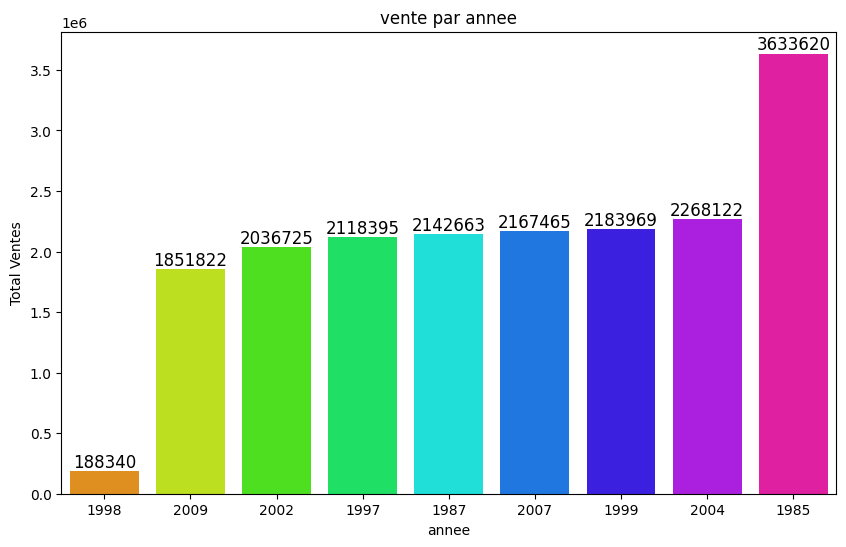

In [23]:
plt.figure(figsize = (10,6))
ax=sns.barplot(x='Outlet_Establishment_Year', y='Item_Outlet_Sales', data = ventesAnnee,palette='hsv')
plt.title('vente par annee')
plt.xlabel('annee')
plt.ylabel('Total Ventes')
for p in ax.patches :
    ax.text(p.get_x() + p.get_width()/2, p.get_height() + 10 ,str(int(p.get_height())),
                ha = 'center', va='bottom', fontsize= 12)
    
plt.show()

In [84]:
# Total vente par type de magasin
vente =df.groupby('Outlet_Type')['Item_Outlet_Sales'].sum().reset_index().sort_values(by='Item_Outlet_Sales',ascending=True)
# vente['Item_Outlet_Sales']=vente['Item_Outlet_Sales'].apply(lambda x: f'{x:.2f}')
vente

,Outlet_Type,Item_Outlet_Sales
0,Grocery Store,368034.266000
2,Supermarket Type2,1851822.830000
3,Supermarket Type3,3453926.051400
1,Supermarket Type1,12917342.263000


C:\Users\user\AppData\Local\Temp\ipykernel_4964\1491537054.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax=sns.barplot(x='Outlet_Type', y='Item_Outlet_Sales', data = vente,palette='hsv')


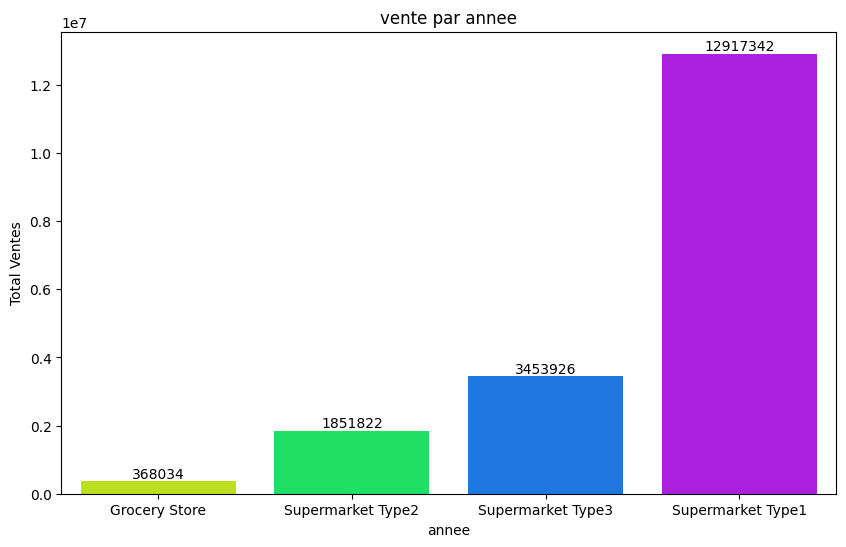

In [85]:
plt.figure(figsize = (10,6))
ax=sns.barplot(x='Outlet_Type', y='Item_Outlet_Sales', data = vente,palette='hsv')
plt.title('vente par annee')
plt.xlabel('annee')
plt.ylabel('Total Ventes')
for p in ax.patches :
    ax.text(p.get_x() + p.get_width()/2, p.get_height() + 10 ,str(int(p.get_height())),
                ha = 'center', va='bottom', fontsize= 10)
    
plt.show()

In [26]:
# Calculer les ventes totales par taille de magasin et type de localisation
vente_Outlet_Size = df.groupby(['Outlet_Size','Outlet_Location_Type'])['Item_Outlet_Sales'].sum().reset_index().sort_values(by='Item_Outlet_Sales',ascending=False)
vente_Outlet_Size

,Outlet_Size,Outlet_Location_Type,Item_Outlet_Sales
0,High,Tier 3,2142663.578200
1,Medium,Tier 1,2183969.810200
2,Medium,Tier 3,5305748.881400
3,Others,Tier 2,4204190.771000
4,Others,Tier 3,188340.172400
5,Small,Tier 1,2298089.261800
6,Small,Tier 2,2268122.935400


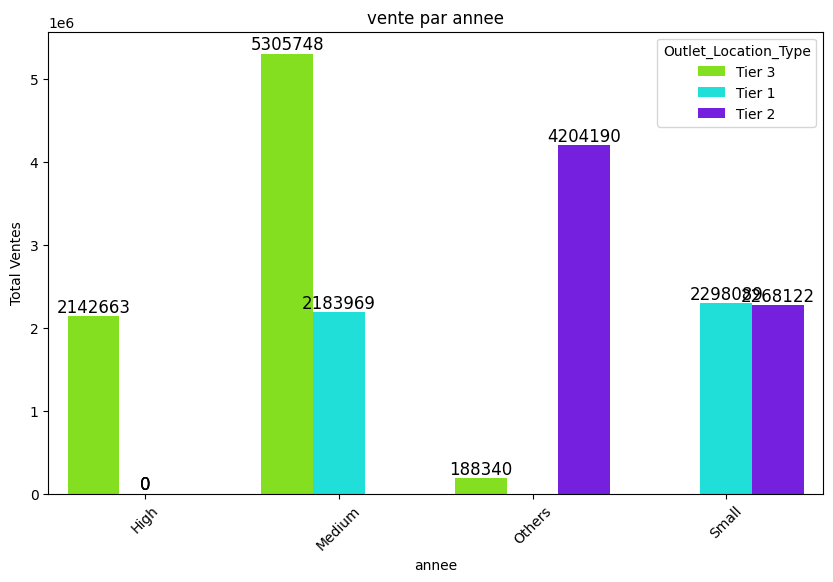

In [27]:
plt.figure(figsize = (10,6))
ax =sns.barplot(x='Outlet_Size', y='Item_Outlet_Sales', data = vente_Outlet_Size,hue='Outlet_Location_Type' ,palette='hsv')
plt.title('vente par annee')
plt.xlabel('annee')
plt.ylabel('Total Ventes')
plt.xticks(rotation=45)

for p in ax.patches :
    ax.text(p.get_x() + p.get_width()/2, p.get_height() + 10 ,str(int(p.get_height())),
                ha = 'center', va='bottom', fontsize= 12)
    
plt.show()
plt.show()

In [28]:
# Nombre de vente par type d'article
df['Item_Type'].value_counts().reset_index()

,Item_Type,count
0,Fruits and Vegetables,1232
1,Snack Foods,1200
2,Household,910
3,Frozen Foods,856
4,Dairy,682
5,Canned,649
6,Baking Goods,648
7,Health and Hygiene,520
8,Soft Drinks,445
9,Meat,425


In [29]:
# Moyenne vente par type d'article
vente_type_article = df.groupby('Item_Type')['Item_Outlet_Sales'].mean().reset_index().sort_values(by='Item_Outlet_Sales', ascending=True)
vente_type_article



,Item_Type,Item_Outlet_Sales
11,Others,1926.139702
0,Baking Goods,1952.971207
14,Soft Drinks,2006.511735
8,Health and Hygiene,2010.000265
2,Breakfast,2111.808651
5,Frozen Foods,2132.867744
7,Hard Drinks,2139.221622
10,Meat,2158.977911
1,Breads,2204.132226
3,Canned,2225.194904


C:\Users\user\AppData\Local\Temp\ipykernel_4964\3304454568.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax= sns.barplot(x='Item_Type', y='Item_Outlet_Sales', data = vente_type_article,palette='viridis')


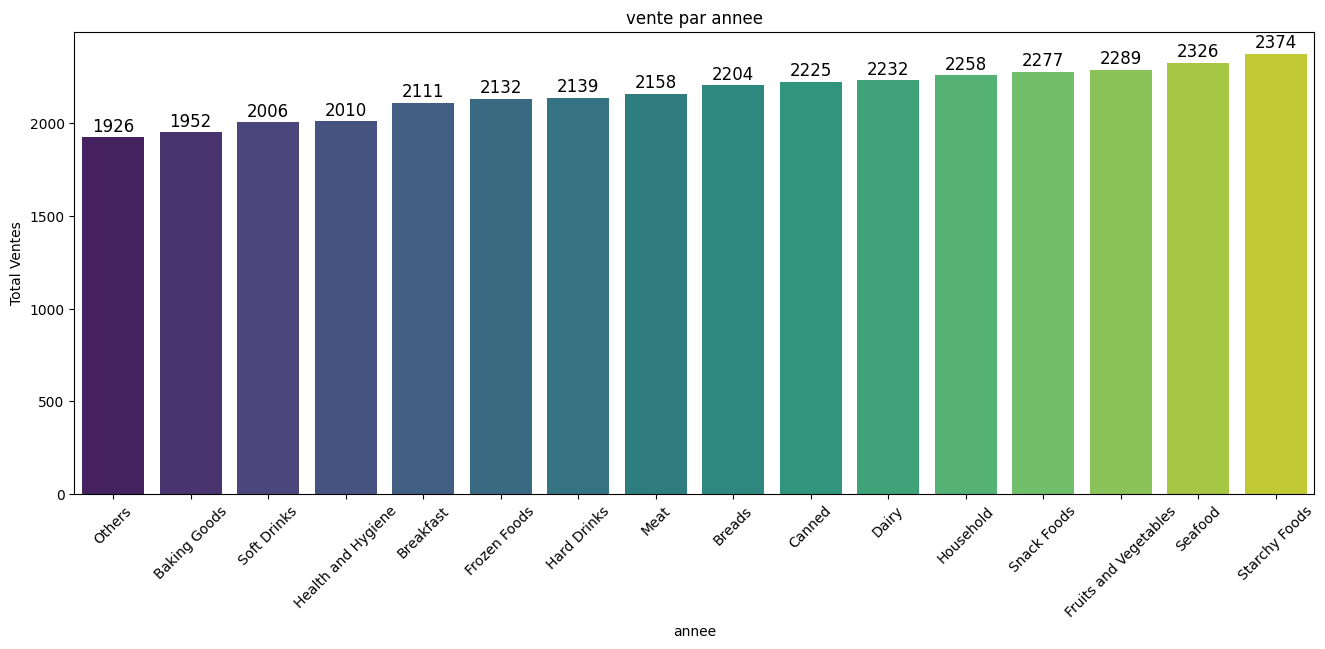

In [30]:
plt.figure(figsize = (16,6))
ax= sns.barplot(x='Item_Type', y='Item_Outlet_Sales', data = vente_type_article,palette='viridis')
plt.title('vente par annee')
plt.xlabel('annee')
plt.ylabel('Total Ventes')
plt.xticks(rotation=45)


for p in ax.patches :
    ax.text(p.get_x() + p.get_width()/2, p.get_height() + 10 ,str(int(p.get_height())),
                ha = 'center', va='bottom', fontsize= 12)
    
plt.show()

In [31]:
# df.to_csv('BigMart_data_cleaned.csv')